NBA Score Prediction - Data Exploration Notebook
=================================================

This notebook explores the Kaggle NBA database to identify relevant tables
and columns for predicting game scores with focus on point differential.

Run this cell by cell to understand the data structure.
"""

In [1]:
import sys
sys.path.append('..')

import sqlite3
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful!")

✓ Imports successful!


# Section 1: DB connection and overview

In [3]:
# Check if data exists
from src.utils import RAW_DATA_DIR

data_path = RAW_DATA_DIR / 'basketball.sqlite'
if data_path.exists():
    print(f"✓ Database found: {data_path}")
    print(f"  Size: {data_path.stat().st_size / (1024**2):.2f} MB")
else:
    print(f"⚠️  Database not found at: {data_path}")
    print("   Download from: https://www.kaggle.com/datasets/wyattowalsh/basketball")

✓ Database found: /Users/omerkoren/dev/nba-score-prediction/notebooks/../data/raw/basketball.sqlite
  Size: 2240.74 MB


In [4]:
conn = sqlite3.connect(data_path)

In [22]:
# Get all tables

tables_query = """
SELECT name, sql 
FROM sqlite_master 
WHERE type='table'
ORDER BY name;
"""
tables_df = pd.read_sql(tables_query, conn)

print(f"\n📊 Total Tables: {len(tables_df)}")
print("\nAvailable Tables:")
for idx, table in enumerate(tables_df['name'], 1):
    row_count = pd.read_sql(f"SELECT COUNT(*) as count FROM {table}", conn)['count'].iloc[0]
    print(f"  {idx:2d}. {table:25s} ({row_count:,} rows)")


📊 Total Tables: 16

Available Tables:
   1. common_player_info        (3,632 rows)
   2. draft_combine_stats       (1,633 rows)
   3. draft_history             (8,257 rows)
   4. game                      (65,698 rows)
   5. game_info                 (58,053 rows)
   6. game_summary              (58,110 rows)
   7. inactive_players          (110,191 rows)
   8. line_score                (58,053 rows)
   9. officials                 (70,971 rows)
  10. other_stats               (28,271 rows)
  11. play_by_play              (13,592,899 rows)
  12. player                    (4,815 rows)
  13. team                      (30 rows)
  14. team_details              (27 rows)
  15. team_history              (50 rows)
  16. team_info_common          (0 rows)


# Section 2: Explore key tables for score prediction

In [29]:
priority_tables = ['game', 'game_info', 'game_summary', 'team', 'line_score']

for table in priority_tables:
    print(f"\n{'='*80}")
    print(f"TABLE: {table}")
    print('='*80)
    
    # Get column information
    columns_df = pd.read_sql(f"PRAGMA table_info({table})", conn)
    print(f"\n📋 Columns ({len(columns_df)}):")
    for _, col in columns_df.iterrows():
        print(f"  - {col['name']:30s} ({col['type']})")
    
    # Get sample data
    print(f"\n📄 Sample Data (first 3 rows):")
    sample = pd.read_sql(f"SELECT * FROM {table} LIMIT 3", conn)
    print(sample)
    
    # Get date range if applicable
    if 'GAME_DATE' in sample.columns or 'GAME_DATE_EST' in sample.columns:
        date_col = 'GAME_DATE' if 'GAME_DATE' in sample.columns else 'GAME_DATE_EST'
        date_range = pd.read_sql(
            f"SELECT MIN({date_col}) as min_date, MAX({date_col}) as max_date FROM {table}", 
            conn
        )
        print(f"\n📅 Date Range: {date_range['min_date'].iloc[0]} to {date_range['max_date'].iloc[0]}")



TABLE: game

📋 Columns (55):
  - season_id                      (TEXT)
  - team_id_home                   (TEXT)
  - team_abbreviation_home         (TEXT)
  - team_name_home                 (TEXT)
  - game_id                        (TEXT)
  - game_date                      (TIMESTAMP)
  - matchup_home                   (TEXT)
  - wl_home                        (TEXT)
  - min                            (INTEGER)
  - fgm_home                       (REAL)
  - fga_home                       (REAL)
  - fg_pct_home                    (REAL)
  - fg3m_home                      (REAL)
  - fg3a_home                      (REAL)
  - fg3_pct_home                   (REAL)
  - ftm_home                       (REAL)
  - fta_home                       (REAL)
  - ft_pct_home                    (REAL)
  - oreb_home                      (REAL)
  - dreb_home                      (REAL)
  - reb_home                       (REAL)
  - ast_home                       (REAL)
  - stl_home                       (RE

# Section 4: Identify features for prediction

In [64]:
print("📊 STATISTICAL FEATURES (from game/team tables):")
stat_features = [
    "Rolling average points scored (last N games)",
    "Rolling average points allowed",
    "Win percentage (last N games)",
    "Home/Away split performance",
    "Rest days since last game",
    "Back-to-back game indicator",
    "Season-to-date offensive/defensive rating",
    "Head-to-head historical performance",
    "Recent form (wins in last 5, 10 games)",
    "Average point differential (last N games)",
]
for i, feature in enumerate(stat_features, 1):
    print(f"  {i:2d}. {feature}")


📊 STATISTICAL FEATURES (from game/team tables):
   1. Rolling average points scored (last N games)
   2. Rolling average points allowed
   3. Win percentage (last N games)
   4. Home/Away split performance
   5. Rest days since last game
   6. Back-to-back game indicator
   7. Season-to-date offensive/defensive rating
   8. Head-to-head historical performance
   9. Recent form (wins in last 5, 10 games)
  10. Average point differential (last N games)


In [66]:
print("📰 NEWS-BASED FEATURES (to be extracted later):")
news_features = [
    "Key player injury status (0-10 scale)",
    "Number of injured starters",
    "Team momentum/narrative sentiment",
    "Coaching changes or controversy",
    "Win/loss streak context",
    "Trade deadline impact",
    "Playoff implications",
]
for i, feature in enumerate(news_features, 1):
    print(f"  {i:2d}. {feature}")

📰 NEWS-BASED FEATURES (to be extracted later):
   1. Key player injury status (0-10 scale)
   2. Number of injured starters
   3. Team momentum/narrative sentiment
   4. Coaching changes or controversy
   5. Win/loss streak context
   6. Trade deadline impact
   7. Playoff implications


# Section 4: Game table deep dive

In [26]:
# Load a sample of game data
game_df = pd.read_sql("SELECT * FROM game WHERE game_date >= '2023-01-01'", conn)

print("\n📊 Game Table Structure:")
print(game_df.info())


📊 Game Table Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   season_id               770 non-null    object 
 1   team_id_home            770 non-null    object 
 2   team_abbreviation_home  770 non-null    object 
 3   team_name_home          770 non-null    object 
 4   game_id                 770 non-null    object 
 5   game_date               770 non-null    object 
 6   matchup_home            770 non-null    object 
 7   wl_home                 770 non-null    object 
 8   min                     770 non-null    int64  
 9   fgm_home                770 non-null    float64
 10  fga_home                770 non-null    float64
 11  fg_pct_home             770 non-null    float64
 12  fg3m_home               770 non-null    float64
 13  fg3a_home               770 non-null    float64
 14  fg3_pct_home     

In [28]:
game_df.game_date.max()

'2023-06-12 00:00:00'

📈 Score Statistics:

Home Team Points:
count    1000.000000
mean      112.980000
std        12.630722
min        73.000000
25%       105.000000
50%       113.000000
75%       121.000000
max       155.000000
Name: pts_home, dtype: float64

Away Team Points:
count    1000.000000
mean      111.692000
std        12.241773
min        76.000000
25%       104.000000
50%       111.500000
75%       120.000000
max       157.000000
Name: pts_away, dtype: float64

Point Differential (Home - Away):
count    1000.000000
mean        1.288000
std        14.382277
min       -51.000000
25%        -9.000000
50%         2.000000
75%        11.000000
max        47.000000
Name: point_diff, dtype: float64

Home Win Rate: 52.40%


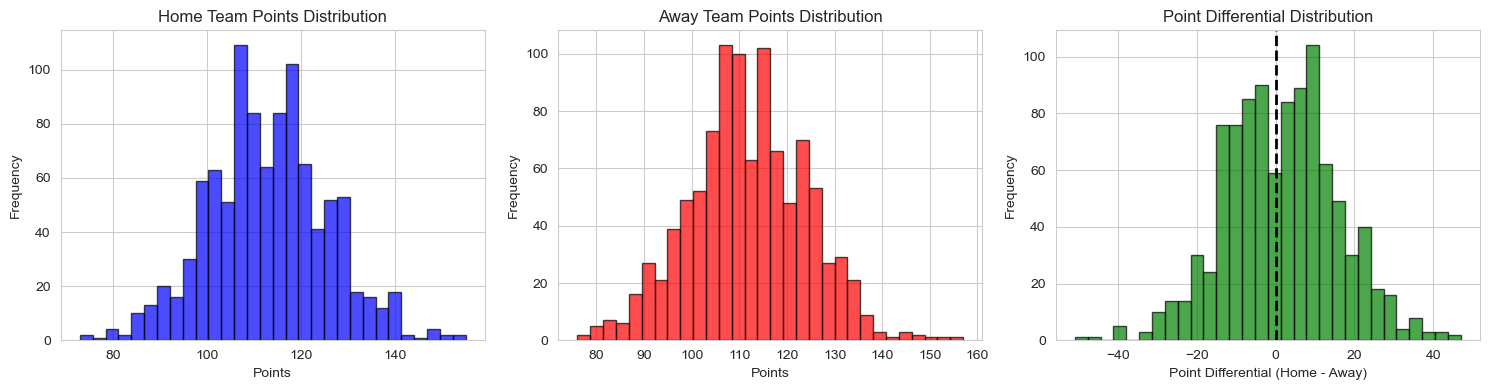

In [40]:
print("📈 Score Statistics:")
if 'pts_home' in game_df.columns and 'pts_away' in game_df.columns:
    game_df['point_diff'] = game_df['pts_home'] - game_df['pts_away']
    
    print(f"\nHome Team Points:")
    print(game_df['pts_home'].describe())
    
    print(f"\nAway Team Points:")
    print(game_df['pts_away'].describe())
    
    print(f"\nPoint Differential (Home - Away):")
    print(game_df['point_diff'].describe())
    
    print(f"\nHome Win Rate: {(game_df['point_diff'] > 0).mean():.2%}")
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].hist(game_df['pts_home'], bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('Home Team Points Distribution')
    axes[0].set_xlabel('Points')
    axes[0].set_ylabel('Frequency')
    
    axes[1].hist(game_df['pts_away'], bins=30, alpha=0.7, color='red', edgecolor='black')
    axes[1].set_title('Away Team Points Distribution')
    axes[1].set_xlabel('Points')
    axes[1].set_ylabel('Frequency')
    
    axes[2].hist(game_df['point_diff'], bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[2].axvline(x=0, color='black', linestyle='--', linewidth=2)
    axes[2].set_title('Point Differential Distribution')
    axes[2].set_xlabel('Point Differential (Home - Away)')
    axes[2].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()


## Section 4.1: Check game data quality

In [50]:
# Check for missing values in key columns
print("\n🔍 Missing Values in Game Table:")
missing = game_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing)
else:
    print("  ✓ No missing values in sample!")


🔍 Missing Values in Game Table:
  ✓ No missing values in sample!


In [54]:
# Check for duplicates
duplicates = game_df.duplicated().sum()
print(f"🔍 Duplicate Rows: {duplicates}")

🔍 Duplicate Rows: 0


In [58]:
[c for c in game_df.columns if "date" in c]

['game_date']

In [60]:
# Check date consistency
if 'game_date' in game_df.columns:
    game_df['game_date'] = pd.to_datetime(game_df['game_date'])
    print(f"\n📅 Date Range in Sample:")
    print(f"  First game: {game_df['game_date'].min()}")
    print(f"  Last game:  {game_df['game_date'].max()}")
    print(f"  Span: {(game_df['game_date'].max() - game_df['game_date'].min()).days} days")


📅 Date Range in Sample:
  First game: 2020-01-01 00:00:00
  Last game:  2021-02-10 00:00:00
  Span: 406 days


# Section 5: Team table exploration

In [73]:
team_df = pd.read_sql("SELECT * FROM team LIMIT 100", conn)
print("\n📋 Team Table Sample:")
print(team_df.head())

print("\n📊 Available Team Stats Columns:")
team_cols = team_df.columns.tolist()
for i, col in enumerate(team_cols, 1):
    print(f"  {i:2d}. {col}")


📋 Team Table Sample:
           id             full_name abbreviation   nickname         city  \
0  1610612737         Atlanta Hawks          ATL      Hawks      Atlanta   
1  1610612738        Boston Celtics          BOS    Celtics       Boston   
2  1610612739   Cleveland Cavaliers          CLE  Cavaliers    Cleveland   
3  1610612740  New Orleans Pelicans          NOP   Pelicans  New Orleans   
4  1610612741         Chicago Bulls          CHI      Bulls      Chicago   

           state  year_founded  
0        Georgia        1949.0  
1  Massachusetts        1946.0  
2           Ohio        1970.0  
3      Louisiana        2002.0  
4       Illinois        1966.0  

📊 Available Team Stats Columns:
   1. id
   2. full_name
   3. abbreviation
   4. nickname
   5. city
   6. state
   7. year_founded


# Section 7: Recommendations

In [75]:
print("\n✅ RECOMMENDED APPROACH:")
print("\n1. PRIMARY DATA SOURCE:")
print("   - Use 'game' table as main source for training data")
print("   - Each row = one game with home/away teams and scores")

print("\n2. FEATURE ENGINEERING:")
print("   - Calculate rolling statistics per team (last 5, 10, 20 games)")
print("   - Create home/away performance splits")
print("   - Add rest days, back-to-back indicators")
print("   - Join with 'team' table for season-level stats")

print("\n3. TARGET VARIABLE:")
print("   - Primary: Point Differential (PTS_home - PTS_away)")
print("   - Secondary: Convert to actual scores using historical distributions")

print("\n4. TRAIN/TEST SPLIT:")
print("   - Use TIME-BASED split (not random!)")
print("   - Train on 2018-2023, validate on 2023-24 season")
print("   - This respects temporal nature of the data")

print("\n5. NEWS FEATURES (Phase 2):")
print("   - Scrape news for each game date")
print("   - Use LLM to extract: injuries, momentum, team chemistry")
print("   - Add as additional features to statistical baseline")

print("\n6. MODEL EVALUATION:")
print("   - Primary Metric: Mean Absolute Error on Point Differential")
print("   - Secondary: Accuracy of predicted score differential within ±5 points")
print("   - Tertiary: Win/Loss prediction accuracy")

print("\n" + "="*80)
print("📝 NEXT STEPS:")
print("="*80)
print("\n1. Create feature engineering pipeline for statistical features")
print("2. Build baseline XGBoost model with stats only")
print("3. Evaluate baseline performance")
print("4. Add news features in Phase 2")
print("5. Compare performance improvement")


✅ RECOMMENDED APPROACH:

1. PRIMARY DATA SOURCE:
   - Use 'game' table as main source for training data
   - Each row = one game with home/away teams and scores

2. FEATURE ENGINEERING:
   - Calculate rolling statistics per team (last 5, 10, 20 games)
   - Create home/away performance splits
   - Add rest days, back-to-back indicators
   - Join with 'team' table for season-level stats

3. TARGET VARIABLE:
   - Primary: Point Differential (PTS_home - PTS_away)
   - Secondary: Convert to actual scores using historical distributions

4. TRAIN/TEST SPLIT:
   - Use TIME-BASED split (not random!)
   - Train on 2018-2023, validate on 2023-24 season
   - This respects temporal nature of the data

5. NEWS FEATURES (Phase 2):
   - Scrape news for each game date
   - Use LLM to extract: injuries, momentum, team chemistry
   - Add as additional features to statistical baseline

6. MODEL EVALUATION:
   - Primary Metric: Mean Absolute Error on Point Differential
   - Secondary: Accuracy of predicte

In [77]:
# Close connection
conn.close()
print("\n✓ Analysis complete! Database connection closed.")


✓ Analysis complete! Database connection closed.


In [85]:
import os
os.getcwd()

'/Users/omerkoren/dev/nba-score-prediction/notebooks'

In [93]:
import os
from pathlib import Path

def print_custom_structure(root_dir):
    root = Path(root_dir)
    print(f"{root.name}/")
    
    # Get all items in the top level
    items = sorted(root.iterdir())
    
    for item in items:
        # Print top-level files and folders
        print(f"├── {item.name}")
        
        # If the item is the 'src' directory, recurse through it
        if item.is_dir() and item.name == "src":
            for sub_root, sub_dirs, sub_files in os.walk(item):
                # Calculate depth relative to 'src' for indentation
                level = Path(sub_root).relative_to(item).parts
                indent = "│   " + "    " * (len(level) + 1)
                
                # Print sub-directories in src
                for d in sub_dirs:
                    print(f"{indent}├── {d}/")
                # Print files in those sub-directories
                for f in sub_files:
                    print(f"{indent}└── {f}")
                
                # We use os.walk's default behavior here, 
                # but you could also limit this if src gets too deep.

print_custom_structure('..')


../
├── .DS_Store
├── .git
├── .gitignore
├── .idea
├── README.md
├── configs
├── data
├── docs
├── notebooks
├── outputs
├── requirements.txt
├── src
│       ├── data_processing/
│       ├── utils/
│       ├── models/
│       ├── __pycache__/
│       ├── news_scraping/
│       ├── feature_engineering/
│       └── .gitkeep
│       └── __init__.py
│           └── .gitkeep
│           └── __init__.py
│           ├── __pycache__/
│           └── .gitkeep
│           └── __init__.py
│               └── __init__.cpython-312.pyc
│           └── .gitkeep
│           └── __init__.py
│           └── __init__.cpython-312.pyc
│           └── .gitkeep
│           └── __init__.py
│           └── .gitkeep
│           └── __init__.py
├── tests
├── venv
